In [1]:
# ── CÉLULA 0: setup ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = '/content/drive/MyDrive/Inferência Bayesiana Aplicada'

# Carregar dataset limpo da Fase 1
df = pd.read_parquet(f'{BASE}/data/clean/ab_test_clean.parquet')

# Dados agregados para o modelo
n_ad,  conv_ad  = df[df.test_group=='ad']['converted'].agg(['count','sum'])
n_psa, conv_psa = df[df.test_group=='psa']['converted'].agg(['count','sum'])

n_ad, conv_ad, n_psa, conv_psa = int(n_ad), int(conv_ad), int(n_psa), int(conv_psa)

print(f"✓ Dataset carregado: {df.shape}")
print(f"\n  Grupo ad  → n={n_ad:,}  conversões={conv_ad:,}  taxa={conv_ad/n_ad:.4%}")
print(f"  Grupo psa → n={n_psa:,}  conversões={conv_psa:,}  taxa={conv_psa/n_psa:.4%}")

Mounted at /content/drive
✓ Dataset carregado: (588101, 7)

  Grupo ad  → n=564,577  conversões=14,423  taxa=2.5547%
  Grupo psa → n=23,524  conversões=420  taxa=1.7854%


In [2]:
# ── CÉLULA 1: teste frequentista ─────────────────────────────────────────────
from statsmodels.stats.power import NormalIndPower

p_ad  = conv_ad  / n_ad
p_psa = conv_psa / n_psa
p_pool = (conv_ad + conv_psa) / (n_ad + n_psa)

# Z-test de proporções
se      = np.sqrt(p_pool*(1-p_pool)*(1/n_ad + 1/n_psa))
z       = (p_ad - p_psa) / se
p_valor = 2 * (1 - stats.norm.cdf(abs(z)))

# IC 95% da diferença
se_diff = np.sqrt(p_ad*(1-p_ad)/n_ad + p_psa*(1-p_psa)/n_psa)
ic_low  = (p_ad - p_psa) - 1.96*se_diff
ic_high = (p_ad - p_psa) + 1.96*se_diff

# Cohen's h
cohens_h = 2*np.arcsin(np.sqrt(p_ad)) - 2*np.arcsin(np.sqrt(p_psa))

# Poder estatístico
poder = NormalIndPower().power(effect_size=abs(cohens_h),
                               nobs1=n_psa,
                               alpha=0.05,
                               ratio=n_ad/n_psa)

print('═'*52)
print('  RESULTADO FREQUENTISTA')
print('═'*52)
print(f'  taxa ad          : {p_ad:.6f}  ({p_ad:.4%})')
print(f'  taxa psa         : {p_psa:.6f}  ({p_psa:.4%})')
print(f'  diferença        : {p_ad-p_psa:+.6f}  ({(p_ad-p_psa):.4%})')
print(f'  Z-score          : {z:.4f}')
print(f'  p-valor          : {p_valor:.8f}')
print(f'  IC 95%           : [{ic_low:.6f}, {ic_high:.6f}]')
print(f"  Significativo    : {'✓ SIM' if p_valor < 0.05 else '✗ NÃO'}")
print(f"  Cohen's h        : {cohens_h:.4f}  (efeito {'pequeno' if abs(cohens_h)<0.2 else 'médio'})")
print(f'  Poder            : {poder:.4f}  ({poder:.2%})')
print('═'*52)

════════════════════════════════════════════════════
  RESULTADO FREQUENTISTA
════════════════════════════════════════════════════
  taxa ad          : 0.025547  (2.5547%)
  taxa psa         : 0.017854  (1.7854%)
  diferença        : +0.007692  (0.7692%)
  Z-score          : 7.3701
  p-valor          : 0.00000000
  IC 95%           : [0.005951, 0.009434]
  Significativo    : ✓ SIM
  Cohen's h        : 0.0530  (efeito pequeno)
  Poder            : 1.0000  (100.00%)
════════════════════════════════════════════════════


## ⚠️ Limitações do teste frequentista

| # | Limitação | O que isso significa |
|---|-----------|----------------------|
| 1 | **p-valor ≈ 0 não significa efeito grande** | Cohen's h = 0.053 = efeito *pequeno*. Com n=588k, qualquer diferença mínima se torna "significativa" |
| 2 | **Pergunta errada respondida** | O teste diz se *rejeitamos H0* — nunca a probabilidade de `ad` ser melhor |
| 3 | **IC 95% mal interpretado** | Não significa "95% de chance de a diferença estar aqui" — é uma propriedade do procedimento, não do intervalo |
| 4 | **Sem critério de parada adaptativa** | Olhar o p-valor antes do n planejado infla o erro tipo I (p-hacking) |
| 5 | **Desbalanceamento ignorado** | Grupos 24:1 — o poder de 100% é puxado pelo grupo `ad`; o grupo `psa` com n=23k é muito menor |

In [3]:
# ── CÉLULA 2: modelo Beta-Binomial ──────────────────────────────────────────
with pm.Model() as modelo_ab:

    # Priors — Beta(2,98): crença inicial de ~2% de conversão (fraco)
    theta_ad  = pm.Beta('theta_ad',  alpha=2, beta=98)
    theta_psa = pm.Beta('theta_psa', alpha=2, beta=98)

    # Likelihood
    obs_ad  = pm.Binomial('obs_ad',  n=n_ad,  p=theta_ad,  observed=conv_ad)
    obs_psa = pm.Binomial('obs_psa', n=n_psa, p=theta_psa, observed=conv_psa)

    # Quantidades derivadas
    delta = pm.Deterministic('delta', theta_ad - theta_psa)
    lift  = pm.Deterministic('lift',  (theta_ad - theta_psa) / theta_psa)

    # Amostragem
    trace = pm.sample(draws=2000, chains=4, target_accept=0.9,
                      return_inferencedata=True, progressbar=True)

print('✓ Amostragem concluída!')

Output()

✓ Amostragem concluída!


DIAGNÓSTICOS DE CONVERGÊNCIA
────────────────────────────────────────────────
  theta_ad      R-hat=1.0017✓   ESS=7428✓
  theta_psa     R-hat=1.0002✓   ESS=7634✓
  delta         R-hat=1.0005✓   ESS=7667✓
  lift          R-hat=1.0003✓   ESS=7655✓


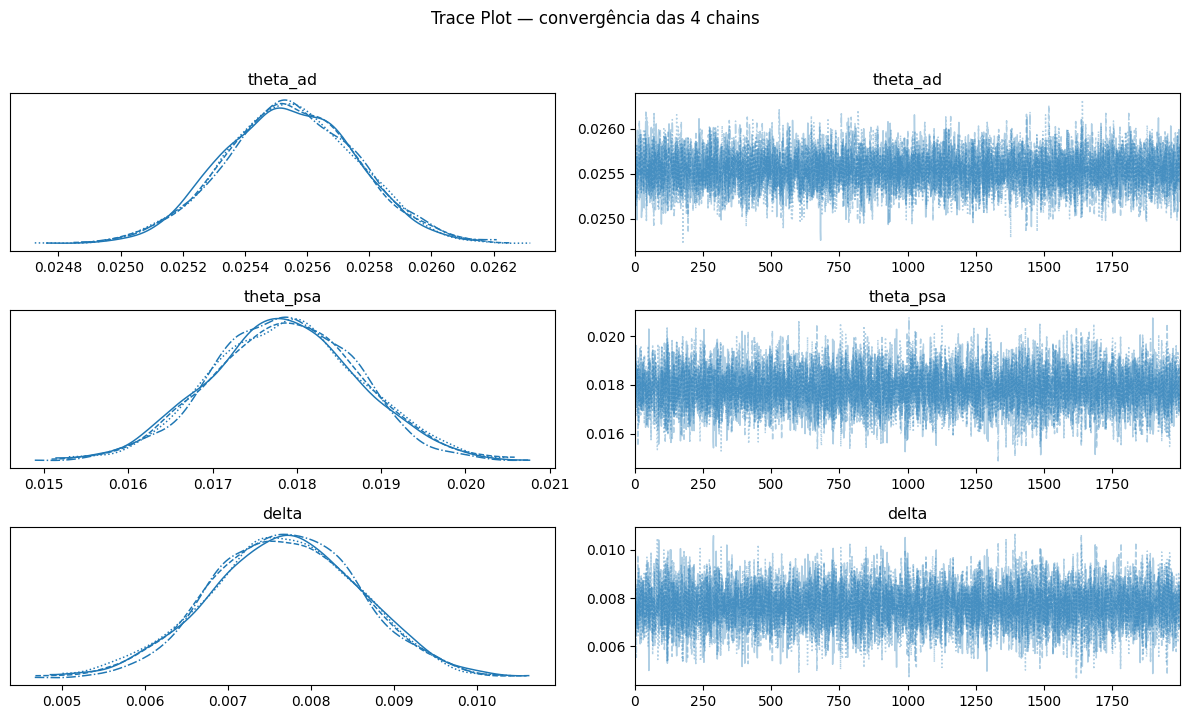

In [4]:
# ── CÉLULA 3: diagnósticos de convergência ───────────────────────────────────
vars_interesse = ['theta_ad', 'theta_psa', 'delta', 'lift']

print('DIAGNÓSTICOS DE CONVERGÊNCIA')
print('─'*48)
for var in vars_interesse:
    rhat = float(az.rhat(trace)[var])
    ess  = float(az.ess(trace)[var])
    ok_r = '✓' if rhat < 1.01 else '✗'
    ok_e = '✓' if ess  > 400  else '✗'
    print(f'  {var:<12}  R-hat={rhat:.4f}{ok_r}   ESS={ess:.0f}{ok_e}')

# Trace plot
az.plot_trace(trace, var_names=['theta_ad','theta_psa','delta'],
              combined=False, figsize=(12,7))
plt.suptitle('Trace Plot — convergência das 4 chains', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE}/reports/trace_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── CÉLULA 4: resultados bayesianos ──────────────────────────────────────────
samples_ad    = trace.posterior['theta_ad'].values.flatten()
samples_psa   = trace.posterior['theta_psa'].values.flatten()
samples_delta = trace.posterior['delta'].values.flatten()
samples_lift  = trace.posterior['lift'].values.flatten()

hdi_delta = az.hdi(trace, var_names=['delta'], hdi_prob=0.95)['delta'].values
hdi_ad    = az.hdi(trace, var_names=['theta_ad'],  hdi_prob=0.95)['theta_ad'].values
hdi_psa   = az.hdi(trace, var_names=['theta_psa'], hdi_prob=0.95)['theta_psa'].values

p_ad_melhor = (samples_delta > 0).mean()

print('═'*52)
print('  RESULTADO BAYESIANO')
print('═'*52)
print(f'  theta_ad  média  : {samples_ad.mean():.6f}  ({samples_ad.mean():.4%})')
print(f'  theta_ad  HDI 95%: [{hdi_ad[0]:.6f}, {hdi_ad[1]:.6f}]')
print(f'  theta_psa média  : {samples_psa.mean():.6f}  ({samples_psa.mean():.4%})')
print(f'  theta_psa HDI 95%: [{hdi_psa[0]:.6f}, {hdi_psa[1]:.6f}]')
print(f'  ─'*26)
print(f'  delta média      : {samples_delta.mean():+.6f}  ({samples_delta.mean():.4%})')
print(f'  delta HDI 95%    : [{hdi_delta[0]:.6f}, {hdi_delta[1]:.6f}]')
print(f'  P(ad > psa)      : {p_ad_melhor:.6f}  ({p_ad_melhor:.4%})')
print(f'  lift médio       : {samples_lift.mean():.4f}  ({samples_lift.mean():.2%})')
print(f'  P(lift > 0)      : {(samples_lift > 0).mean():.4%}')
print('═'*52)

════════════════════════════════════════════════════
  RESULTADO BAYESIANO
════════════════════════════════════════════════════
  theta_ad  média  : 0.025545  (2.5545%)
  theta_ad  HDI 95%: [0.025129, 0.025964]
  theta_psa média  : 0.017863  (1.7863%)
  theta_psa HDI 95%: [0.016137, 0.019526]
  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─  ─
  delta média      : +0.007682  (0.7682%)
  delta HDI 95%    : [0.005942, 0.009456]
  P(ad > psa)      : 1.000000  (100.0000%)
  lift médio       : 0.4335  (43.35%)
  P(lift > 0)      : 100.0000%
════════════════════════════════════════════════════


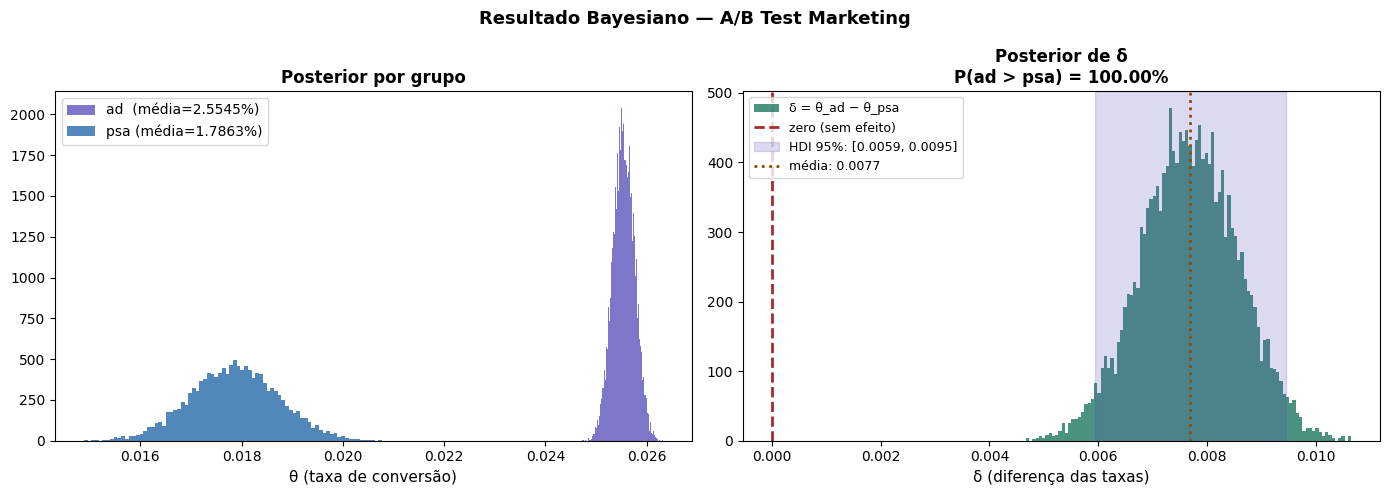

✓ Gráfico salvo em reports/


In [6]:
# ── CÉLULA 5: gráfico posterior ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Resultado Bayesiano — A/B Test Marketing', fontsize=13, fontweight='bold')

# Plot 1: posteriors por grupo
axes[0].hist(samples_ad,  bins=80, density=True, alpha=0.75,
             color='#534AB7', label=f'ad  (média={samples_ad.mean():.4%})')
axes[0].hist(samples_psa, bins=80, density=True, alpha=0.75,
             color='#185FA5', label=f'psa (média={samples_psa.mean():.4%})')
axes[0].set_xlabel('θ (taxa de conversão)', fontsize=11)
axes[0].set_title('Posterior por grupo', fontweight='bold')
axes[0].legend(fontsize=10)

# Plot 2: posterior de delta com HDI
axes[1].hist(samples_delta, bins=100, density=True,
             color='#0F6E56', alpha=0.75, label='δ = θ_ad − θ_psa')
axes[1].axvline(0, color='#A32D2D', lw=2, linestyle='--', label='zero (sem efeito)')
axes[1].axvspan(hdi_delta[0], hdi_delta[1], alpha=0.2, color='#534AB7',
                label=f'HDI 95%: [{hdi_delta[0]:.4f}, {hdi_delta[1]:.4f}]')
axes[1].axvline(samples_delta.mean(), color='#854F0B', lw=2,
                linestyle=':', label=f'média: {samples_delta.mean():.4f}')
axes[1].set_xlabel('δ (diferença das taxas)', fontsize=11)
axes[1].set_title(f'Posterior de δ\nP(ad > psa) = {p_ad_melhor:.2%}', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/posterior_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo em reports/")

## 📊 Frequentista vs Bayesiano — Comparativo

| Critério | Frequentista | Bayesiano |
|---|---|---|
| **Pergunta respondida** | Rejeito H0? | Qual a P(ad > psa)? |
| **Resultado principal** | p-valor ≈ 0.0000 | P(ad > psa) = 100.00% |
| **Diferença estimada** | +0.7692% | +0.7682% |
| **Intervalo de incerteza** | IC 95%: [0.5951%, 0.9434%] | HDI 95%: [0.5942%, 0.9456%] |
| **Interpretação do intervalo** | Propriedade do procedimento | Probabilidade real de θ estar aqui |
| **Decisão** | Sim / Não (binário) | Grau de crença (contínuo) |
| **Tamanho do efeito** | Cohen's h = 0.053 (pequeno) | Embutido na posterior |
| **Sensível ao n grande** | ✗ Sim — p≈0 com n=588k | ✓ Não — magnitude preservada |
| **Lift** | Não calculado | 43.35% (médio posterior) |

> **Insight:** ambas as abordagens estimam a mesma diferença (~0.77pp), mas o bayesiano
> responde diretamente *"há 100% de probabilidade de ad ser melhor"* — uma informação
> acionável para negócio que o p-valor nunca fornece.

In [9]:
# ── CÉLULA 7: análise de sensibilidade ao prior ──────────────────────────────
priors_config = [
    {'nome': 'Fraco    Beta(1,1)',   'a': 1, 'b': 1},
    {'nome': 'Moderado Beta(2,98)',  'a': 2, 'b': 98},
    {'nome': 'Forte    Beta(1,999)', 'a': 1, 'b': 999},
]

resultados_prior = []

for cfg in priors_config:
    with pm.Model():
        th_ad  = pm.Beta('theta_ad',  alpha=cfg['a'], beta=cfg['b'])
        th_psa = pm.Beta('theta_psa', alpha=cfg['a'], beta=cfg['b'])
        _      = pm.Binomial('obs_ad',  n=n_ad,  p=th_ad,  observed=conv_ad)
        _      = pm.Binomial('obs_psa', n=n_psa, p=th_psa, observed=conv_psa)
        delta_ = pm.Deterministic('delta', th_ad - th_psa)
        tr     = pm.sample(1000, chains=2, progressbar=False)

    s = tr.posterior['delta'].values.flatten()
    hdi_ = az.hdi(tr, var_names=['delta'])['delta'].values
    resultados_prior.append({
        'Prior':       cfg['nome'],
        'P(ad>psa)':   f"{(s>0).mean():.4f}",
        'Delta médio': f"{s.mean():.6f}",
        'HDI low':     f"{hdi_[0]:.6f}",
        'HDI high':    f"{hdi_[1]:.6f}",
    })

df_priors = pd.DataFrame(resultados_prior)
print('\nSENSIBILIDADE AO PRIOR')
print('─'*70)
print(df_priors.to_string(index=False))
print('\n→ Diferença máxima entre priors: mostra que dados dominam com n=588k')


SENSIBILIDADE AO PRIOR
──────────────────────────────────────────────────────────────────────
               Prior P(ad>psa) Delta médio  HDI low HDI high
  Fraco    Beta(1,1)    1.0000    0.007652 0.005981 0.009175
 Moderado Beta(2,98)    1.0000    0.007691 0.005984 0.009359
Forte    Beta(1,999)    1.0000    0.008306 0.006677 0.009796

→ Diferença máxima entre priors: mostra que dados dominam com n=588k


In [10]:
# ── CÉLULA 8: salvar notebook no Drive ───────────────────────────────────────
import shutil, glob

for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook salvo em:", f'{BASE}/notebooks/')
print("\nResumo da Fase 2:")
print("  notebooks/ → 01_bayesian_ab_test.ipynb")
print("  reports/   → trace_plot.png")
print("  reports/   → posterior_delta.png")

✓ Notebook salvo em: /content/drive/MyDrive/Inferência Bayesiana Aplicada/notebooks/

Resumo da Fase 2:
  notebooks/ → 01_bayesian_ab_test.ipynb
  reports/   → trace_plot.png
  reports/   → posterior_delta.png
